In [1]:
%env ECOLOGICAL_NEURO_DATA_ROOT=/media/labuser/NA_1_2025/EcoNeuro

env: ECOLOGICAL_NEURO_DATA_ROOT=/media/labuser/NA_1_2025/EcoNeuro


In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import os
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import savgol_filter
from src.ecological_neuro.interactive import *
from src.ecological_neuro.plotting import *
from src.ecological_neuro.utils import *

sns.set_theme(context='talk', style='ticks', palette='colorblind')
PALETTE = sns.color_palette('colorblind')
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Explore bat free-flight data (Demo_Session, bat 14543, 2024-04-19)

`Extracted_Behavior_240419.mat` gives 3D room position (`r`), velocity (`v`/`v_abs`), and a `bflying` flag segmented into `f_num` discrete flights (`f_smp` gives each flight's start/stop sample, 1-indexed). Each flight is treated as a trial, analogous to a monkey reach: the bat flies from a takeoff point and lands, decelerating on approach. The landing point (the flight's final sampled position) plays the role of the reach target.

No units/documentation ship with this dataset. `r_lim` (~+/-2.9 x +/-2.6 x 0-2.3) suggests `r` is in meters; treat all downstream units as provisional pending confirmation from the data provider.

In [3]:
behavior_path = Path(os.environ['ECOLOGICAL_NEURO_DATA_ROOT']) / 'Demo_Session' / 'Extracted_Behavior_240419.mat'
behavior = loadmat(behavior_path)

sample_rate_hz = float(np.squeeze(behavior['Fs']))
time_all = np.squeeze(behavior['t']).astype(float)
position_all = np.asarray(behavior['r'], dtype=float)
speed_all = np.squeeze(behavior['v_abs']).astype(float)
flight_bounds = np.asarray(behavior['f_smp'], dtype=int)

print(f'{sample_rate_hz} Hz, {len(time_all)} samples, {len(flight_bounds)} flights')

120.0 Hz, 642724 samples, 38 flights


In [4]:
start_idx = flight_bounds[:, 0] - 1
stop_idx = flight_bounds[:, 1]

flights = pd.DataFrame({
    'flight': np.arange(len(start_idx)),
    'start_time': time_all[start_idx],
    'stop_time': time_all[stop_idx - 1],
})
flights['time'] = [time_all[i:j] for i, j in zip(start_idx, stop_idx)]
flights['position'] = [position_all[i:j] for i, j in zip(start_idx, stop_idx)]
flights['landing_position'] = flights['position'].apply(lambda position: position[-1])
flights['speed'] = [speed_all[i:j] for i, j in zip(start_idx, stop_idx)]

In [5]:
SMOOTHING_SIGMA_S = 0.10
MAX_GAP_MULTIPLIER = 3.0

def calculate_flight_kinematics(row):
    speed_smoothed = smooth_time_series(
        row['time'], row['speed'], smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    acceleration = differentiate_time_series(
        row['time'], speed_smoothed, max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    return pd.Series({
        'speed_smoothed': speed_smoothed,
        'acceleration': acceleration,
    })

flights[['speed_smoothed', 'acceleration']] = flights.apply(calculate_flight_kinematics, axis=1)

In [6]:
def path_efficiency(position):
    if len(position) < 15:
        return np.nan
    smoothed = savgol_filter(position, 15, 2, axis=0)
    path_length = np.linalg.norm(np.diff(smoothed, axis=0), axis=1).sum()
    return np.linalg.norm(smoothed[-1] - smoothed[0]) / path_length

flights['path_efficiency'] = flights['position'].apply(path_efficiency)
straight_flights = flights[flights['path_efficiency'] >= 0.90].copy()
print(f'{len(straight_flights)} of {len(flights)} flights retained as direct approaches')

11 of 38 flights retained as direct approaches


In [7]:
MIN_BRAKING_DURATION_S = 0.20
MAX_ACCELERATION_INTERRUPTION_S = 0.05

def find_braking_period(row):
    event = detect_braking_period(
        row['time'], row['acceleration'], np.ones(len(row['time']), dtype=bool),
        len(row['time']) - 1, min_duration_s=MIN_BRAKING_DURATION_S,
        max_interruption_s=MAX_ACCELERATION_INTERRUPTION_S,
    )
    if event is None:
        return pd.Series({'braking_detected': False})

    onset_position = row['position'][event.start_index]
    return pd.Series({
        'braking_detected': True,
        'braking_onset_index': event.start_index,
        'braking_onset_time': event.start_time_s,
        'braking_duration_s': event.duration_s,
        'braking_negative_fraction': event.negative_fraction,
        'braking_onset_x': onset_position[0],
        'braking_onset_y': onset_position[1],
    })

braking_columns = straight_flights.apply(find_braking_period, axis=1)
straight_flights[braking_columns.columns] = braking_columns
detected_braking_flights = straight_flights[straight_flights['braking_detected']].copy()
print(f'{len(detected_braking_flights)} of {len(straight_flights)} direct flights have detected braking')

11 of 11 direct flights have detected braking


In [8]:
@widgets.interact(flight=widgets.Dropdown(options=detected_braking_flights['flight'], description='Flight:'))
def plot_flight(flight):
    row = detected_braking_flights.loc[detected_braking_flights['flight'] == flight].iloc[0]
    position = row['position']
    speed = row['speed_smoothed']

    fig, ax = plt.subplots(figsize=(4, 4))
    trajectory = ax.scatter(position[:, 0], position[:, 1], c=speed, s=10, cmap='viridis')
    ax.scatter(*position[0, :2], marker='o', s=100, color='black', label='Takeoff')
    ax.scatter(*position[-1, :2], marker='*', s=200, color='orange', label='Landing')
    ax.scatter(row['braking_onset_x'], row['braking_onset_y'], marker='x', s=150, color='red', linewidths=3, label='Braking onset')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend()
    fig.colorbar(trajectory, ax=ax, label='Speed (m/s)')
    plt.show()

interactive(children=(Dropdown(description='Flight:', options=(11, 12, 18, 20, 22, 24, 26, 28, 29, 30, 32), va…

In [9]:
@widgets.interact(flight=widgets.Dropdown(options=detected_braking_flights['flight'], description='Flight:'))
def plot_flight_acceleration(flight):
    row = detected_braking_flights.loc[detected_braking_flights['flight'] == flight].iloc[0]
    position = row['position']
    acceleration = row['acceleration']
    color_limit = np.nanpercentile(np.abs(acceleration), 99)

    fig, ax = plt.subplots(figsize=(4, 4))
    trajectory = ax.scatter(
        position[:, 0], position[:, 1], c=acceleration, s=10, cmap='RdBu',
        vmin=-color_limit, vmax=color_limit,
    )
    ax.scatter(*position[0, :2], marker='o', s=100, color='black', label='Takeoff')
    ax.scatter(*position[-1, :2], marker='*', s=200, color='orange', label='Landing')
    ax.scatter(row['braking_onset_x'], row['braking_onset_y'], marker='x', s=150, color='red', linewidths=3, label='Braking onset')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend()
    fig.colorbar(trajectory, ax=ax, label='Acceleration (m/s\u00b2)')
    plt.show()

interactive(children=(Dropdown(description='Flight:', options=(11, 12, 18, 20, 22, 24, 26, 28, 29, 30, 32), va…

In [10]:
MIN_CLOSURE_SPEED_M_S = 0.1

metric_rows = []
for row in detected_braking_flights.itertuples(index=False):
    onset_index = int(row.braking_onset_index)
    arrival_index = len(row.time) - 1
    remaining_gap = np.linalg.norm(row.position - row.landing_position, axis=1)
    smoothed_gap = smooth_time_series(
        row.time, remaining_gap, smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    total_gap_closed = smoothed_gap[0] - smoothed_gap[arrival_index]
    normalized_distance = (
        (smoothed_gap[0] - smoothed_gap[onset_index]) / total_gap_closed
        if np.isfinite(total_gap_closed) and total_gap_closed > 0 else np.nan
    )
    metrics = calculate_braking_metrics(
        row.time, remaining_gap, row.speed_smoothed, row.acceleration,
        onset_index, arrival_index, closure_speed_floor=MIN_CLOSURE_SPEED_M_S,
        smoothing_sigma_s=SMOOTHING_SIGMA_S, max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    metric_rows.append({
        'flight': row.flight,
        'path_efficiency': row.path_efficiency,
        'landing_x_m': row.landing_position[0],
        'landing_y_m': row.landing_position[1],
        'position_x_m': row.braking_onset_x,
        'position_y_m': row.braking_onset_y,
        'normalized_distance_at_onset': normalized_distance,
        **vars(metrics),
    })

spatial_metric_names = {
    'remaining_gap_at_onset': 'remaining_gap_at_onset_m',
    'closure_speed_at_onset': 'closure_speed_at_onset_m_s',
    'speed_at_onset': 'speed_at_onset_m_s',
    'acceleration_at_onset': 'acceleration_at_onset_m_s2',
    'speed_at_arrival': 'speed_at_arrival_m_s',
    'speed_reduction': 'speed_reduction_m_s',
    'distance_travelled': 'distance_travelled_m',
    'mean_deceleration': 'mean_deceleration_m_s2',
    'max_deceleration': 'max_deceleration_m_s2',
}
braking_metrics_df = pd.DataFrame(metric_rows).rename(columns=spatial_metric_names)

breaking_onset_metrics = braking_metrics_df[[
    'flight', 'path_efficiency', 'time_to_arrival_s', 'remaining_gap_at_onset_m',
    'normalized_distance_at_onset',
    'closure_speed_at_onset_m_s', 'tau_at_onset_s', 'speed_at_onset_m_s',
    'acceleration_at_onset_m_s2',
]].copy()
breaking_onset_metrics.head()

,flight,path_efficiency,time_to_arrival_s,remaining_gap_at_onset_m,normalized_distance_at_onset,closure_speed_at_onset_m_s,tau_at_onset_s,speed_at_onset_m_s,acceleration_at_onset_m_s2
0,11,0.933514,1.233333,2.808256,0.432484,3.574105,0.785723,3.752362,-0.026009
1,12,0.927762,0.891666,2.293612,0.492674,3.273464,0.700668,3.423260,-0.028743
2,18,0.955976,0.758334,2.315946,0.549629,4.005736,0.578157,4.127421,-0.048693
3,20,0.941489,0.825000,2.410086,0.525649,3.767084,0.639775,3.871462,-0.041051
4,22,0.949623,0.741666,2.219700,0.565129,3.908989,0.567845,4.020694,-0.045866


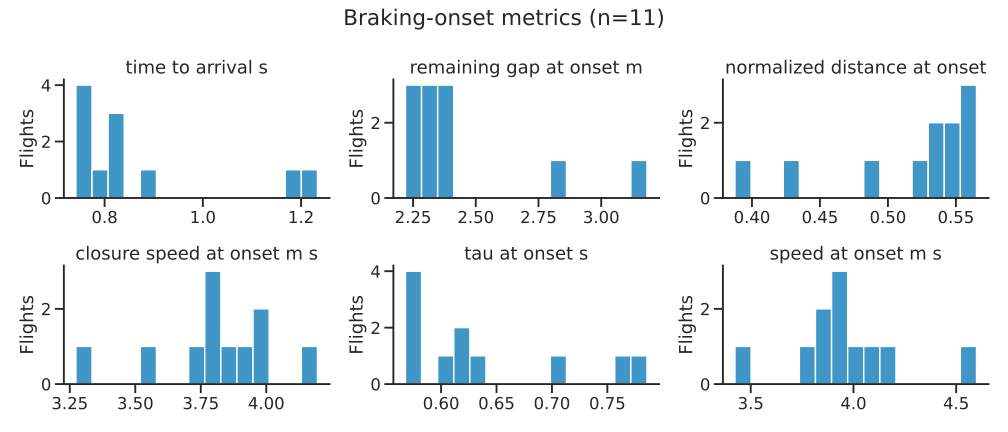

In [11]:
onset_metric_columns = [
    'time_to_arrival_s',
    'remaining_gap_at_onset_m',
    'normalized_distance_at_onset',
    'closure_speed_at_onset_m_s',
    'tau_at_onset_s',
    'speed_at_onset_m_s',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), layout='tight')
for ax, metric in zip(axes.flat, onset_metric_columns):
    sns.histplot(breaking_onset_metrics[metric].dropna(), bins=15, ax=ax, color=PALETTE[0])
    ax.set(title=metric.replace('_', ' '), xlabel='', ylabel='Flights')
for ax in axes.flat[len(onset_metric_columns):]:
    ax.remove()
fig.suptitle(f'Braking-onset metrics (n={len(breaking_onset_metrics)})')
plt.show()

In [12]:
selected_metrics = breaking_onset_metrics[onset_metric_columns]
medians = selected_metrics.median()
iqrs = selected_metrics.quantile(0.75) - selected_metrics.quantile(0.25)
normalized_iqr_table = pd.DataFrame({
    'median': medians,
    'iqr': iqrs,
    'normalized_iqr': iqrs / medians.abs().replace(0, np.nan),
}).sort_values('normalized_iqr')
normalized_iqr_table

,median,iqr,normalized_iqr
closure_speed_at_onset_m_s,3.824615,0.185449,0.048488
remaining_gap_at_onset_m,2.324353,0.114235,0.049147
speed_at_onset_m_s,3.957595,0.208146,0.052594
normalized_distance_at_onset,0.535760,0.043478,0.081153
time_to_arrival_s,0.816667,0.100000,0.122449
tau_at_onset_s,0.620454,0.089547,0.144325


## Does this session have enough independent distance/speed variation to test tau?

Only 38 flights exist in total, and the `path_efficiency >= 0.90` filter above already narrows that to a handful of direct point-to-point flights. Before trusting any tau-vs-distance-vs-speed comparison, check whether distance and speed vary independently enough in this small sample, mirroring the confound check run on the monkey reach data.

In [ ]:
support_rows = []
for row in straight_flights.itertuples(index=False):
    remaining_gap = np.linalg.norm(row.position - row.landing_position, axis=1)
    smoothed_gap = smooth_time_series(
        row.time, remaining_gap, smoothing_sigma_s=SMOOTHING_SIGMA_S,
        max_gap_multiplier=MAX_GAP_MULTIPLIER,
    )
    support_rows.append({
        'flight': row.flight,
        'total_distance_m': smoothed_gap[0] - smoothed_gap[-1],
        'peak_speed_m_s': np.nanmax(row.speed_smoothed),
    })

straight_flight_support = pd.DataFrame(support_rows)
onset_support = breaking_onset_metrics[[
    'flight', 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s',
]].dropna()

In [ ]:
support_plots = [
    (straight_flight_support, 'total_distance_m', 'peak_speed_m_s', 'Complete flights'),
    (onset_support, 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s', 'At braking onset'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, x, y, title) in zip(axes, support_plots):
    ax.scatter(data[x], data[y], s=20, alpha=0.7)
    for value in data[x].quantile([0.25, 0.75]):
        ax.axvline(value, color='grey', linestyle='--')
    for value in data[y].quantile([0.25, 0.75]):
        ax.axhline(value, color='grey', linestyle='--')
    ax.set(xlabel=x.replace('_', ' '), ylabel=y.replace('_', ' '), title=title)
plt.show()

In [ ]:
def summarize_support(data, x, y, comparison):
    x25, x75 = data[x].quantile([0.25, 0.75])
    y25, y75 = data[y].quantile([0.25, 0.75])
    return {
        'comparison': comparison,
        'n': len(data),
        'pearson_r': data[[x, y]].corr().iloc[0, 1],
        'spearman_rho': data[[x, y]].corr(method='spearman').iloc[0, 1],
        'low_distance_low_speed_n': ((data[x] <= x25) & (data[y] <= y25)).sum(),
        'low_distance_high_speed_n': ((data[x] <= x25) & (data[y] >= y75)).sum(),
        'high_distance_low_speed_n': ((data[x] >= x75) & (data[y] <= y25)).sum(),
        'high_distance_high_speed_n': ((data[x] >= x75) & (data[y] >= y75)).sum(),
    }

behavioral_support_report = pd.DataFrame([
    summarize_support(
        straight_flight_support, 'total_distance_m', 'peak_speed_m_s',
        'Total distance vs peak speed',
    ),
    summarize_support(
        onset_support, 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s',
        'Onset gap vs closure speed',
    ),
])
print('Low/high groups are the bottom/top quartiles; the middle 50% is not counted.')
behavioral_support_report

In [ ]:
distance_bin_labels = ['Q1 shortest', 'Q2', 'Q3', 'Q4', 'Q5 longest']

straight_flight_support_binned = straight_flight_support.copy()
straight_flight_support_binned['distance_bin'] = pd.qcut(
    straight_flight_support_binned['total_distance_m'], 5, labels=distance_bin_labels,
)

onset_support_binned = onset_support.copy()
onset_support_binned['distance_bin'] = pd.qcut(
    onset_support_binned['remaining_gap_at_onset_m'], 5, labels=distance_bin_labels,
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(
    data=straight_flight_support_binned, x='distance_bin', y='peak_speed_m_s',
    ax=axes[0], color=PALETTE[0],
)
sns.boxplot(
    data=onset_support_binned, x='distance_bin', y='closure_speed_at_onset_m_s',
    ax=axes[1], color=PALETTE[0],
)
axes[0].set(title='Peak speed within total-distance bins', xlabel='Total-distance quintile')
axes[1].set(title='Closure speed within onset-gap bins', xlabel='Onset-gap quintile')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.show()

In [ ]:
def summarize_conditional_support(data, distance, speed, comparison):
    grouped = data.groupby('distance_bin', observed=True)
    bin_report = grouped.agg(
        n=(speed, 'size'),
        distance_min=(distance, 'min'),
        distance_max=(distance, 'max'),
        speed_q25=(speed, lambda values: values.quantile(0.25)),
        speed_median=(speed, 'median'),
        speed_q75=(speed, lambda values: values.quantile(0.75)),
    )
    bin_report['speed_iqr'] = bin_report['speed_q75'] - bin_report['speed_q25']
    bin_report['normalized_speed_iqr'] = bin_report['speed_iqr'] / bin_report['speed_median']
    residual_speed = data[speed] - grouped[speed].transform('mean')
    within_distance = data[distance] - grouped[distance].transform('mean')
    return bin_report, {
        'comparison': comparison,
        'remaining_speed_variance_fraction': residual_speed.var() / data[speed].var(),
        'pooled_within_bin_r': within_distance.corr(residual_speed),
    }

full_bin_report, full_summary = summarize_conditional_support(
    straight_flight_support_binned, 'total_distance_m', 'peak_speed_m_s',
    'Total distance vs peak speed',
)
onset_bin_report, onset_summary = summarize_conditional_support(
    onset_support_binned, 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s',
    'Onset gap vs closure speed',
)
conditional_support_summary = pd.DataFrame([full_summary, onset_summary])
display(conditional_support_summary)
display(full_bin_report)
display(onset_bin_report)

In [ ]:
MATCH_DISTANCE_TOLERANCE_M = 0.05
MIN_MATCH_SPEED_RATIO = 1.5

full_match_candidates = find_distance_matched_pairs(
    straight_flight_support['flight'], straight_flight_support['total_distance_m'],
    straight_flight_support['peak_speed_m_s'],
    max_distance_difference=MATCH_DISTANCE_TOLERANCE_M,
    min_speed_ratio=MIN_MATCH_SPEED_RATIO,
)
onset_match_candidates = find_distance_matched_pairs(
    onset_support['flight'], onset_support['remaining_gap_at_onset_m'],
    onset_support['closure_speed_at_onset_m_s'],
    max_distance_difference=MATCH_DISTANCE_TOLERANCE_M,
    min_speed_ratio=MIN_MATCH_SPEED_RATIO,
)
full_matched_pairs = full_match_candidates[full_match_candidates['selected']] if len(full_match_candidates) else full_match_candidates
onset_matched_pairs = onset_match_candidates[onset_match_candidates['selected']] if len(onset_match_candidates) else onset_match_candidates

In [ ]:
matched_pair_plots = [
    (straight_flight_support, full_matched_pairs, 'total_distance_m', 'peak_speed_m_s', 'Complete flights'),
    (onset_support, onset_matched_pairs, 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s', 'At braking onset'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, pairs, distance, speed, title) in zip(axes, matched_pair_plots):
    ax.scatter(data[distance], data[speed], s=15, color='lightgrey')
    for pair in pairs.itertuples(index=False):
        matched = data[data['flight'].isin([pair.first_id, pair.second_id])]
        ax.plot(matched[distance], matched[speed], color=PALETTE[0], alpha=0.7)
        ax.scatter(matched[distance], matched[speed], s=25, color=PALETTE[0])
    ax.set(xlabel=distance.replace('_', ' '), ylabel=speed.replace('_', ' '))
    ax.set_title(f'{title} (n={len(pairs)} pairs)')
plt.show()

In [ ]:
def matched_pair_summary(candidates, comparison, total_flights, tolerance, speed_ratio):
    if len(candidates):
        eligible_flights = set(candidates['first_id']) | set(candidates['second_id'])
        candidate_n = len(candidates)
        selected_n = int(candidates['selected'].sum())
    else:
        eligible_flights = set()
        candidate_n = 0
        selected_n = 0
    return {
        'comparison': comparison,
        'distance_tolerance_m': tolerance,
        'minimum_speed_ratio': speed_ratio,
        'total_flights': total_flights,
        'candidate_pair_n': candidate_n,
        'eligible_flight_n': len(eligible_flights),
        'non_reused_pair_n': selected_n,
    }

primary_match_report = pd.DataFrame([
    matched_pair_summary(
        full_match_candidates, 'Total distance vs peak speed', len(straight_flight_support),
        MATCH_DISTANCE_TOLERANCE_M, MIN_MATCH_SPEED_RATIO,
    ),
    matched_pair_summary(
        onset_match_candidates, 'Onset gap vs closure speed', len(onset_support),
        MATCH_DISTANCE_TOLERANCE_M, MIN_MATCH_SPEED_RATIO,
    ),
])

sensitivity_rows = []
for comparison, data, distance, speed in [
    ('Total distance vs peak speed', straight_flight_support, 'total_distance_m', 'peak_speed_m_s'),
    ('Onset gap vs closure speed', onset_support, 'remaining_gap_at_onset_m', 'closure_speed_at_onset_m_s'),
]:
    for tolerance in [0.02, 0.05, 0.1, 0.2, 0.5]:
        for speed_ratio in [1.1, 1.25, 1.5, 2.0]:
            candidates = find_distance_matched_pairs(
                data['flight'], data[distance], data[speed],
                max_distance_difference=tolerance, min_speed_ratio=speed_ratio,
            )
            sensitivity_rows.append(matched_pair_summary(
                candidates, comparison, len(data), tolerance, speed_ratio,
            ))
distance_match_sensitivity = pd.DataFrame(sensitivity_rows)
display(primary_match_report)
distance_match_sensitivity